In [1]:
import specula
specula.init(-1)  # Default target device
from specula import np

from specula.data_objects.pixels import Pixels
import matplotlib.pyplot as plt

from specula.data_objects.electric_field import ElectricField
from specula.data_objects.simul_params import SimulParams
from specula.lib.make_mask import make_mask
from specula.lib.zernike_generator import ZernikeGenerator
from specula.processing_objects.zernike_sensor import ZernikeSensor

from specula.processing_objects.zwfs_slopec import ZwfsSlopec

Cupy import successfull. Installed version is: 13.6.0
Default device is CPU


FoV reduction from 2.06 to 2.00 will be performed with a focal plane mask
FoV reduction from 2.06 to 2.00 will be performed with a focal plane mask
FoV reduction from 2.06 to 2.00 will be performed with a focal plane mask
Cached circular modulation with 1 steps, amplitude: 0.00
[2537.05224609]
[0.92246315]
Cached circular modulation with 1 steps, amplitude: 0.00


/home/matte/git/SPECULA/specula/processing_objects/modulated_pyramid.py:359: RuntimeWarning: divide by zero encountered in scalar divide
  'tilt_scale': fft_res / ((pup_dist / float(pup_diam)) / 2.0),


[3426.54125977]
[0.96549005]
Cached circular modulation with 1 steps, amplitude: 0.00
[4241.40576172]
[0.99072736]


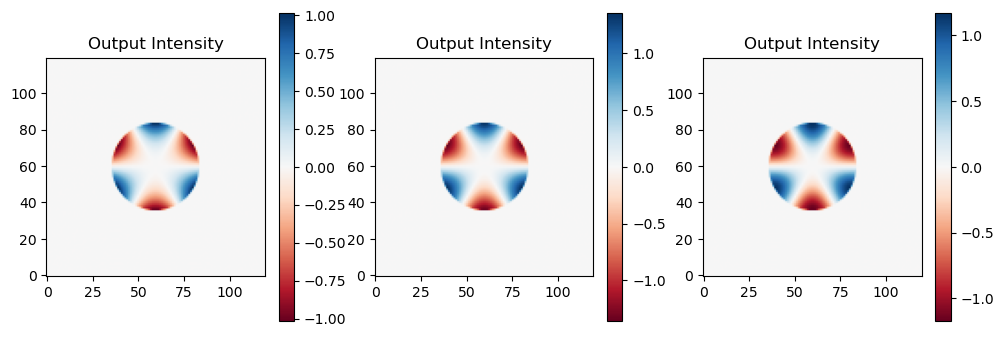

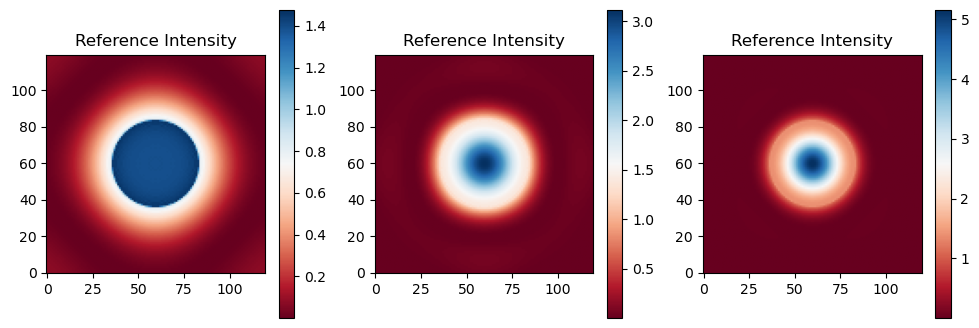

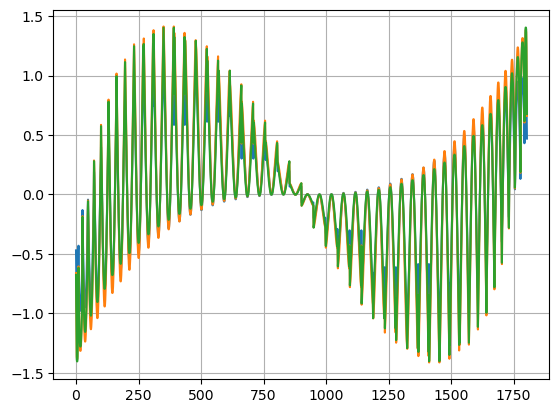

In [2]:
t = 1
pixel_pupil = 160
pixel_pitch = 0.05
wavelength_nm = 500
fov = 2.0
pup_diam = 48
output_resolution = 120
ref_S0 = 100

# Create simulation parameters
simul_params = SimulParams(
    pixel_pupil=pixel_pupil,
    pixel_pitch=pixel_pitch
)

slopec = ZwfsSlopec(pup_diam=pup_diam, ccd_size=output_resolution, target_device_idx=-1)

# Create Zernike sensor
zwfs = ZernikeSensor(
    simul_params=simul_params,
    wavelengthInNm=wavelength_nm,
    spot_radius_lambda=0.5,
    # phase_shift=0.8,
    fov=fov,
    pup_diam=pup_diam,
    output_resolution=output_resolution,
    target_device_idx=-1
)
z15wfs = ZernikeSensor(
    simul_params=simul_params,
    wavelengthInNm=wavelength_nm,
    spot_radius_lambda=0.75,
    fov=fov,
    pup_diam=pup_diam,
    output_resolution=output_resolution,
    target_device_idx=-1
)
z2wfs = ZernikeSensor(
    simul_params=simul_params,
    wavelengthInNm=wavelength_nm,
    spot_radius_lambda=1.0,
    fov=fov,
    pup_diam=pup_diam,
    output_resolution=output_resolution,
    target_device_idx=-1
)
pixels = Pixels(pixel_pupil, pixel_pupil, target_device_idx=-1)

ef = ElectricField(pixel_pupil, pixel_pupil, pixel_pitch, S0=ref_S0, target_device_idx=-1)
ef.A = make_mask(pixel_pupil)

def get_intentities(zernike_sensor,noll:int,ampInNm:float=15):
    zg = ZernikeGenerator(ef.size[0], xp=np, dtype=ef.dtype)
    phaseInNm = zg.getZernike(noll)*ampInNm
    ef.phaseInNm = phaseInNm
    ef.generation_time = t

    zernike_sensor.inputs['in_ef'].set(ef)
    zernike_sensor.setup()
    zernike_sensor.check_ready(t)
    zernike_sensor.trigger()
    zernike_sensor.post_trigger()
    intensity = zernike_sensor.outputs['out_i']
    intensity_diff = intensity.i.copy()
    pixels.pixels = intensity.i.copy()
    pixels.generation_time = t
    slopec.inputs['in_pixels'].set(pixels)
    slopec.check_ready(t)
    slopec.trigger()
    slopec.post_trigger()
    slopesA = slopec.outputs['out_slopes'].slopes.copy()
    
    ef.phaseInNm[:] = -phaseInNm
    ef.generation_time = 2*t
    zernike_sensor.check_ready(2*t)
    zernike_sensor.trigger()
    zernike_sensor.post_trigger()
    intensity_diff -= intensity.i.copy()
    pixels.pixels = intensity.i.copy()
    pixels.generation_time = t*2
    slopec.inputs['in_pixels'].set(pixels)
    slopec.check_ready(2*t)
    slopec.trigger()
    slopec.post_trigger()
    slopesB = slopec.outputs['out_slopes'].slopes.copy()

    ef.phaseInNm[:] = phaseInNm*0.
    ef.generation_time = 3*t
    zernike_sensor.check_ready(3*t)
    zernike_sensor.trigger()
    zernike_sensor.post_trigger()
    intensity_ref = intensity.i.copy()  
    pixels.pixels = intensity.i.copy()
    pixels.generation_time = t*3
    slopec.inputs['in_pixels'].set(pixels)  
    slopec.check_ready(3*t)
    slopec.trigger()
    slopec.post_trigger()
    slopes_null = slopec.outputs['out_slopes'].slopes.copy()
    print(slopec.outputs['out_total_counts'].value)
    print(zernike_sensor.transmission.value)

    return intensity_diff/2, intensity_ref, np.stack([slopesA,slopesB,slopes_null])

noll = 9

zwfs_frame, zwfs_ref, slopes1 = get_intentities(zwfs,noll)
z15wfs_frame, z15wfs_ref, slopes15  = get_intentities(z15wfs,noll)
z2wfs_frame, z2wfs_ref, slopes2  = get_intentities(z2wfs,noll)

plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.imshow(zwfs_frame,origin='lower',cmap='RdBu')
plt.title("Output Intensity")
plt.colorbar()
plt.subplot(1,3,2)
plt.imshow(z15wfs_frame,origin='lower',cmap='RdBu')
plt.title("Output Intensity")
plt.colorbar()
plt.subplot(1,3,3)
plt.imshow(z2wfs_frame,origin='lower',cmap='RdBu')
plt.title("Output Intensity")
plt.colorbar()

plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.imshow(zwfs_ref,origin='lower',cmap='RdBu')
plt.title("Reference Intensity")
plt.colorbar()
plt.subplot(1,3,2)
plt.imshow(z15wfs_ref,origin='lower',cmap='RdBu')
plt.title("Reference Intensity")
plt.colorbar()
plt.subplot(1,3,3)
plt.imshow(z2wfs_ref,origin='lower',cmap='RdBu')
plt.title("Reference Intensity")
plt.colorbar()

plt.figure()
plt.plot(slopes2[0]-slopes2[1])
plt.plot(slopes15[0]-slopes15[1])
plt.plot(slopes1[0]-slopes1[1])
# plt.plot(slopes[2])
plt.grid()

In [5]:
ef.masked_area()

np.float64(50.27000000000001)

In [3]:

ccd_size = output_resolution
zwfs_mask = make_mask(np_size=ccd_size, diaratio = pup_diam/ccd_size, obsratio=0.0)

z1wfs_thrp = np.sum(zwfs_ref[zwfs_mask.astype(bool)])/np.sum(zwfs_ref)
z15wfs_thrp = np.sum(z15wfs_ref[zwfs_mask.astype(bool)])/np.sum(z15wfs_ref)
z2wfs_thrp = np.sum(z2wfs_ref[zwfs_mask.astype(bool)])/np.sum(z2wfs_ref)
print(z1wfs_thrp,z15wfs_thrp,z2wfs_thrp)
print(np.sum(zwfs_ref),np.sum(z15wfs_ref),np.sum(z2wfs_ref),)

0.5471060689902055 0.7059911360032045 0.8516218399331823
4637.222242229695 4853.518471494597 4980.386438290963
